In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("creditcard.csv")[:80_000]
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,37332.183588,-0.258086,-0.036364,0.678340,0.163600,-0.276254,0.095376,-0.114390,0.053252,-0.010000,...,-0.029000,-0.105751,-0.037651,0.007894,0.134427,0.026336,0.002025,0.002570,97.775498,0.002450
std,15209.718131,1.888947,1.679465,1.386402,1.368678,1.382928,1.305057,1.247498,1.233289,1.144390,...,0.739825,0.636423,0.628525,0.595679,0.440853,0.498120,0.390666,0.331055,269.180362,0.049437
min,0.000000,-56.407510,-72.715728,-33.680984,-5.172595,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-26.751119,-2.836627,-7.495741,-2.534330,-9.390980,-9.617915,0.000000,0.000000
25%,30718.500000,-1.019388,-0.599350,0.186697,-0.725926,-0.894690,-0.642417,-0.604450,-0.141200,-0.686546,...,-0.224356,-0.524838,-0.178315,-0.322913,-0.129354,-0.326741,-0.063341,-0.005819,7.680000,0.000000
50%,40052.000000,-0.250144,0.069013,0.765189,0.182134,-0.309687,-0.153999,-0.073816,0.069079,-0.089189,...,-0.058577,-0.080453,-0.050284,0.064108,0.172777,-0.072778,0.009277,0.022868,26.955000,0.000000
75%,49105.000000,1.153620,0.721751,1.394244,1.043840,0.258717,0.490107,0.416536,0.349036,0.624249,...,0.117690,0.309546,0.080590,0.405444,0.421519,0.307898,0.082446,0.076056,89.205000,0.000000
max,58287.000000,1.960497,18.902453,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,10.503090,18.946734,4.014444,5.525093,3.517346,12.152401,33.847808,19656.530000,1.000000


In [4]:
X = df.drop(columns=["Time","Amount","Class"]).values
y = df['Class'].values
X.shape, y.shape, y.sum()

((80000, 28), (80000,), 196)

In [5]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

In [23]:
from collections import Counter
from sklearn.ensemble import IsolationForest
ift = IsolationForest().fit(X)
Counter(ift.predict(X))

Counter({1: 76894, -1: 3106})

In [24]:
(ift.predict(X) == 0).astype(int)

array([0, 0, 0, ..., 0, 0, 0])

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer

def min_both(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return min(p, r)

def outlier_precision(y_true, y_pred):
    y_pred = (y_pred == -1).astype(int)
    return precision_score(y_true, y_pred)

def outlier_recall(y_true, y_pred):
    y_pred = (y_pred == -1).astype(int)
    return recall_score(y_true, y_pred)

grid = GridSearchCV( estimator=ift,
                    # param_grid={'class_weight': [{0:1, 1:n} for n in np.linspace(1,20,30)]},
                    param_grid={'contamination': np.linspace(0.001, 0.02, 10)},
                    cv=5,
                    # scoring={"precision":make_scorer(precision_score), "recall":make_scorer(recall_score), "min_both":make_scorer(min_both)},
                    scoring={"precision":make_scorer(outlier_precision), "recall":make_scorer(outlier_recall)},
                    refit="precision",
                    return_train_score=True,
                    n_jobs=-1
                    )
grid.fit(X,y)

,estimator,IsolationForest()
,param_grid,"{'contamination': array([0.001 ..., 0.02 ])}"
,scoring,"{'precision': make_scorer(o...hod='predict'), 'recall': make_scorer(o...hod='predict')}"
,n_jobs,-1
,refit,'precision'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [7]:
s = make_scorer(min_both)
??s

Signature:       s(estimator, X, y_true, sample_weight=None, **kwargs)
Type:            _Scorer
String form:     make_scorer(min_both, response_method='predict')
File:            c:\users\sride\appdata\local\programs\python\python312\lib\site-packages\sklearn\metrics\_scorer.py
Source:         
class _Scorer(_BaseScorer):
    def _score(self, method_caller, estimator, X, y_true, **kwargs):
        """Evaluate the response method of `estimator` on `X` and `y_true`.

        Parameters
        ----------
        method_caller : callable
            Returns predictions given an estimator, method name, and other
            arguments, potentially caching results.

        estimator : object
            Trained estimator to use for scoring.

        X : {array-like, sparse matrix}
            Test data that will be fed to clf.decision_function or
            clf.predict_proba.

        y_true : array-like
            Gold standard target values for X. These must be class labels,
           

In [31]:
df = pd.DataFrame(grid.cv_results_)
df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_contamination,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,...,mean_test_recall,std_test_recall,rank_test_recall,split0_train_recall,split1_train_recall,split2_train_recall,split3_train_recall,split4_train_recall,mean_train_recall,std_train_recall
0,2.084744,0.117182,0.316329,0.054823,0.001000,{'contamination': 0.001},0.651163,0.000000,0.724138,0.000000,...,0.170046,0.209914,10,0.195122,0.215569,0.245033,0.220339,0.234940,0.222201,0.017113
1,2.311744,0.073750,0.339502,0.068612,0.003111,{'contamination': 0.003111111111111111},0.422222,0.282051,0.545455,0.000000,...,0.386638,0.221941,9,0.430894,0.407186,0.390728,0.406780,0.512048,0.429527,0.043205
2,1.915103,0.346332,0.332038,0.054176,0.005222,{'contamination': 0.005222222222222222},0.289062,0.162791,0.480000,0.039216,...,0.458974,0.222596,8,0.471545,0.502994,0.569536,0.553672,0.542169,0.527983,0.035770
3,2.349487,0.232346,0.366346,0.034869,0.007333,{'contamination': 0.007333333333333333},0.288557,0.141414,0.300000,0.039474,...,0.520368,0.248909,7,0.585366,0.556886,0.549669,0.666667,0.560241,0.583766,0.043159
4,1.880583,0.091712,0.287082,0.031424,0.009444,{'contamination': 0.009444444444444443},0.244240,0.160305,0.236111,0.030303,...,0.566056,0.229331,6,0.560976,0.706587,0.569536,0.683616,0.674699,0.639083,0.061231
5,2.418497,0.762896,0.403000,0.060585,0.011556,{'contamination': 0.011555555555555555},0.221790,0.113514,0.223464,0.023810,...,0.590349,0.270760,5,0.585366,0.724551,0.642384,0.689266,0.722892,0.672892,0.052968
6,2.440295,0.675354,0.382153,0.051357,0.013667,{'contamination': 0.013666666666666667},0.186246,0.100503,0.175115,0.022059,...,0.623148,0.264330,4,0.674797,0.712575,0.582781,0.745763,0.759036,0.694990,0.063226
7,2.777021,0.388783,0.365715,0.025520,0.015778,{'contamination': 0.015777777777777776},0.175676,0.091667,0.164659,0.017857,...,0.650274,0.280554,3,0.699187,0.766467,0.721854,0.796610,0.777108,0.752245,0.036132
8,1.903086,0.069063,0.287863,0.029689,0.017889,{'contamination': 0.017888888888888888},0.153302,0.089552,0.143885,0.014925,...,0.666289,0.280780,2,0.723577,0.754491,0.615894,0.813559,0.759036,0.733312,0.065470
9,1.880662,0.101544,0.275309,0.028342,0.020000,{'contamination': 0.02},0.144470,0.083032,0.117302,0.017316,...,0.667180,0.255950,1,0.691057,0.796407,0.695364,0.841808,0.789157,0.762759,0.059600


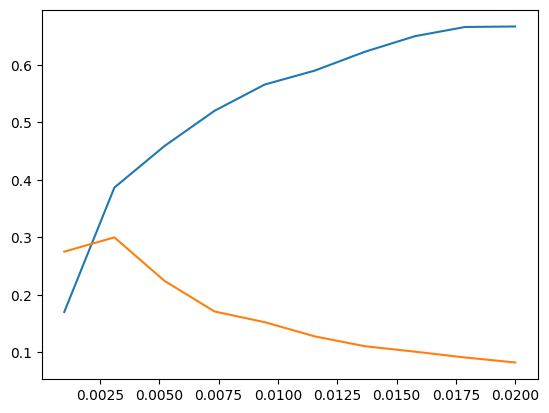

In [33]:
y_param = "param_contamination"#'param_class_weight'
plt.plot(df[y_param], grid.cv_results_['mean_test_recall'], label="test precision")
plt.plot(df[y_param], grid.cv_results_['mean_test_precision'], label="test recall")
# plt.plot([_[1] for _ in df['param_class_weight']], grid.cv_results_['mean_test_min_both'], label="test min both")

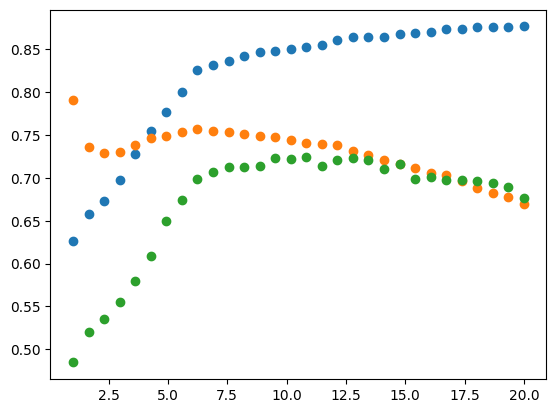

In [10]:
plt.scatter([_[1] for _ in df['param_class_weight']], grid.cv_results_['mean_train_recall'], label="train precision")
plt.scatter([_[1] for _ in df['param_class_weight']], grid.cv_results_['mean_train_precision'], label="train recall")
plt.scatter([_[1] for _ in df['param_class_weight']], grid.cv_results_['mean_test_min_both'], label="train min both")

In [11]:
y_pred = grid.predict(X)
y_pred.sum()

211

In [12]:
precision_score(y,y_pred), recall_score(y,y_pred)

(0.7962085308056872, 0.8571428571428571)